In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_root = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis/brain_region_traces'
outdir = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis/effect_size'
os.makedirs(outdir, exist_ok=True)

use_detrended = True
variant = 'detrended' if use_detrended else 'original'
suffix = '_detrended' if use_detrended else ''

compounds = ['control', 'PTZ', 'Tricaine']
colors = {'control': 'steelblue', 'PTZ': 'firebrick', 'Tricaine': '#7CA82A'}  # a bit darker than yellowgreen

selected_fish = {
    'control':  ['fish01', 'fish02', 'fish04', 'fish06', 'fish09'],
    'Tricaine': ['fish02', 'fish04', 'fish06', 'fish07', 'fish10'],
    'PTZ':      ['fish04', 'fish08', 'fish09', 'fish11', 'fish12'],
}

baseline_window = (90, 180)
plateau_frames = 30   # frames before washout defining the late-stimulus plateau
stim_events = [
    {'name': 'stimulus_1', 'full': (185, 370), 'washout': 370},
    {'name': 'stimulus_2', 'full': (647, 832), 'washout': 832},
]
window_modes = ['full', 'plateau']
metrics = ['dff_change', 'cohens_d', 'd_baseline']
main_divisions = ['Telencephalon', 'Diencephalon', 'Mesencephalon', 'Rhombencephalon']


**Load region-mean traces**

In [3]:
def load_all_fish(compound):

    pattern = f'{data_root}/{compound}/fish*_{compound}_mean_traces_all_regions{suffix}.csv'
    keep = set(selected_fish[compound])
    fish = {}
    for fp in sorted(glob.glob(pattern)):
        fish_id = os.path.basename(fp).split('_')[0]
        if fish_id in keep:
            fish[fish_id] = pd.read_csv(fp, index_col=0).select_dtypes(include=[np.number])
    if not fish:
        raise FileNotFoundError(f'no selected fish matched {pattern}')
        
    return fish

In [4]:
def is_whole_division(region):
    # True for the whole-division masks like 'Telencephalon -'
    r = region.strip()
    return ' - ' not in r and r.endswith('-')
    

**Effect size metrics**

In [5]:
# for one region trace, one stimulation, one window mode
def effect_metrics_one(trace, event, mode):

    b0, b1 = baseline_window
    if mode == 'full':
        s0, s1 = event['full']
    else:  # late-stimulus plateau
        s0, s1 = event['washout'] - plateau_frames, event['washout']
    base = np.asarray(trace[b0:b1], float)
    stim = np.asarray(trace[s0:s1], float)

    mean_base, mean_stim = base.mean(), stim.mean()
    sd_base, sd_stim = base.std(ddof=1), stim.std(ddof=1)
    nb, ns = base.size, stim.size
    pooled = np.sqrt(((nb - 1) * sd_base**2 + (ns - 1) * sd_stim**2) / max(nb + ns - 2, 1))
    diff = mean_stim - mean_base
    
    return {'mean_base': mean_base, 'mean_stim': mean_stim,
            'dff_change': diff,
            'cohens_d': (diff / pooled) if pooled > 1e-9 else np.nan,
            'd_baseline': (diff / sd_base) if sd_base > 1e-9 else np.nan}
    

**Build effect-size table for all fish**

In [6]:
# one row per (compound, fish, region, event, mode), plus averaged rows (event='mean')

def build_effect_table():

    rows = []
    for compound in compounds:
        fish = load_all_fish(compound)
        regions = sorted(set.intersection(*[set(df.columns) for df in fish.values()]))
        for fish_id, df in fish.items():
            for region in regions:
                trace = df[region].to_numpy()
                for event in stim_events:
                    for mode in window_modes:
                        rows.append({'compound': compound, 'fish': fish_id, 'region': region,
                                     'major': region.split(' - ')[0].strip(),
                                     'event': event['name'], 'mode': mode,
                                     **effect_metrics_one(trace, event, mode)})
    tbl = pd.DataFrame(rows)
    averaged = (tbl.groupby(['compound', 'fish', 'region', 'major', 'mode'],
                            as_index=False)[metrics].mean())
    averaged['event'] = 'mean'
    
    return pd.concat([tbl, averaged], ignore_index=True)

In [7]:
# division level effect sizes, one value per fish and division
def per_fish_division(tbl):

    sub = tbl[tbl['region'].map(is_whole_division)].copy()
    sub['major'] = sub['region'].str.replace(r'\s*-\s*$', '', regex=True)
    cols = ['compound', 'fish', 'major', 'event', 'mode'] + metrics
    
    return sub[cols].sort_values(cols[:5]).reset_index(drop=True)

**Bootstrap Summary across fish**

In [8]:
# resample fish with replacement
def bootstrap_ci(values, n_boot=10000, ci=95, seed=0):

    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    
    return float(v.mean()), float(lo), float(hi)

In [9]:
# mean, bootsrap CI, SD, CV per compound, group, event and mode

def group_summary(per_fish_tbl, by='major'):

    rows = []
    for (compound, group, event, mode), g in per_fish_tbl.groupby(['compound', by, 'event',
                                                                   'mode']):
        rec = {'compound': compound, by: group, 'event': event, 'mode': mode, 'n_fish': len(g)}
        for m in metrics:
            v = g[m].to_numpy(float)
            v = v[~np.isnan(v)]
            mean, lo, hi = bootstrap_ci(v)
            sd = float(np.std(v, ddof=1)) if v.size > 1 else np.nan
            rec[f'{m}_mean'] = mean
            rec[f'{m}_lo'] = lo
            rec[f'{m}_hi'] = hi
            rec[f'{m}_sd'] = sd
            rec[f'{m}_cv'] = (sd / abs(mean)) if (mean and np.isfinite(mean)) else np.nan
        rows.append(rec)
        
    return pd.DataFrame(rows)
    

**Plotting**

In [10]:
# grouped bar chart

def plot_metric_by_division(pfd, metric='dff_change', event='mean', mode='full', ylabel=None,
                            path_to_save=None):

    rng = np.random.default_rng(0)
    sub = pfd[(pfd.event == event) & (pfd['mode'] == mode)]
    fig, ax = plt.subplots(figsize=(1.6 * len(main_divisions) + 2, 4.3))
    width = 0.25
    
    for ci, compound in enumerate(compounds):
        for di, division in enumerate(main_divisions):
            v = sub[(sub.compound == compound) & (sub.major == division)][metric].to_numpy(float)
            v = v[~np.isnan(v)]
            x = di + (ci - 1) * width
            mean, lo, hi = bootstrap_ci(v)
            ax.bar(x, mean, width=width, color=colors[compound], alpha=0.85,
                   label=compound if di == 0 else None)
            ax.errorbar(x, mean, yerr=[[mean - lo], [hi - mean]], fmt='none', ecolor='k',
                        capsize=3, lw=1)
            ax.scatter(x + rng.uniform(-0.06, 0.06, v.size), v, color='k', s=12,
                       alpha=0.6, zorder=3)
            
    ax.axhline(0, color='k', lw=0.6, alpha=0.6)
    ax.set_xticks(range(len(main_divisions)))
    ax.set_xticklabels(main_divisions, rotation=20, ha='right')
    ax.set_ylabel(ylabel or metric, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    # ax.set_title(f'{ylabel or metric} per division', fontsize=14)
    ax.legend(frameon=False, fontsize=12)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, ax

**Run analysis and save results as csv files**

In [11]:
tbl = build_effect_table()
tbl.to_csv(f'{outdir}/effect_size_per_region_{variant}.csv', index=False)

pfd = per_fish_division(tbl)
pfd.to_csv(f'{outdir}/effect_size_per_fish_division_{variant}.csv', index=False)

**Group summaries per division and region**

In [12]:
summary_division = group_summary(pfd, by='major')
summary_division.to_csv(f'{outdir}/effect_size_summary_division_{variant}.csv', index=False)

In [13]:
fine = tbl[~tbl['region'].map(is_whole_division)]
summary_region = group_summary(fine, by='region')
summary_region.to_csv(f'{outdir}/effect_size_summary_region_{variant}.csv', index=False)

In [14]:
view = summary_division[(summary_division.event == 'mean') &
                        (summary_division['mode'] == 'full')]
show_cols = ['compound', 'major', 'n_fish', 'dff_change_mean', 'dff_change_lo',
             'dff_change_hi', 'dff_change_cv', 'cohens_d_mean', 'cohens_d_cv',
             'd_baseline_mean']
view[show_cols].round(3).sort_values(['major', 'compound'])

,compound,major,n_fish,dff_change_mean,dff_change_lo,dff_change_hi,dff_change_cv,cohens_d_mean,cohens_d_cv,d_baseline_mean
0,PTZ,Diencephalon,5,0.285,0.214,0.346,0.297,1.924,0.034,13.909
24,Tricaine,Diencephalon,5,0.012,0.002,0.030,1.638,0.210,0.976,0.626
48,control,Diencephalon,5,0.017,0.002,0.033,1.191,0.597,1.231,1.439
6,PTZ,Mesencephalon,5,0.241,0.176,0.301,0.337,1.868,0.050,15.614
30,Tricaine,Mesencephalon,5,0.013,0.002,0.030,1.504,0.304,1.159,0.749
54,control,Mesencephalon,5,0.007,-0.005,0.019,2.177,0.369,2.237,0.792
12,PTZ,Rhombencephalon,5,0.140,0.100,0.180,0.372,1.454,0.172,7.829
36,Tricaine,Rhombencephalon,5,0.066,0.053,0.084,0.321,1.619,0.232,3.764
60,control,Rhombencephalon,5,0.020,0.013,0.027,0.478,0.500,0.481,1.341
18,PTZ,Telencephalon,5,0.141,0.109,0.172,0.298,1.925,0.371,5.476


**Effect size per division**

(<Figure size 840x430 with 1 Axes>, <Axes: ylabel='ΔF/F change'>)

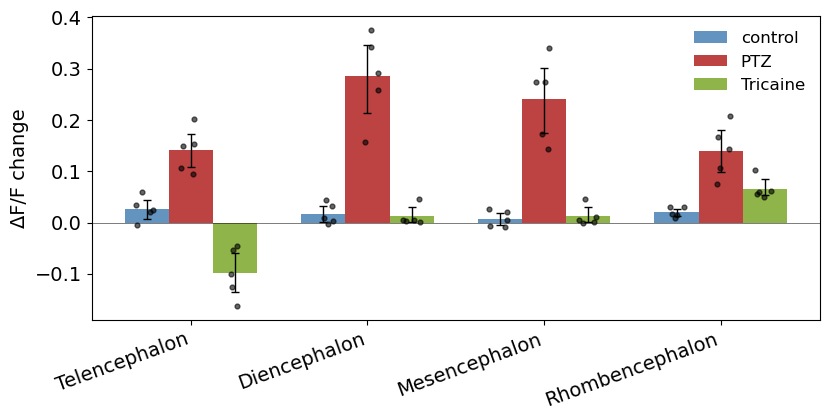

In [15]:
plot_metric_by_division(pfd, 'dff_change', ylabel='ΔF/F change',
                        path_to_save=f'{outdir}/dff_change_by_division_full_mean_{variant}.pdf')

(<Figure size 840x430 with 1 Axes>, <Axes: ylabel="Cohen's d">)

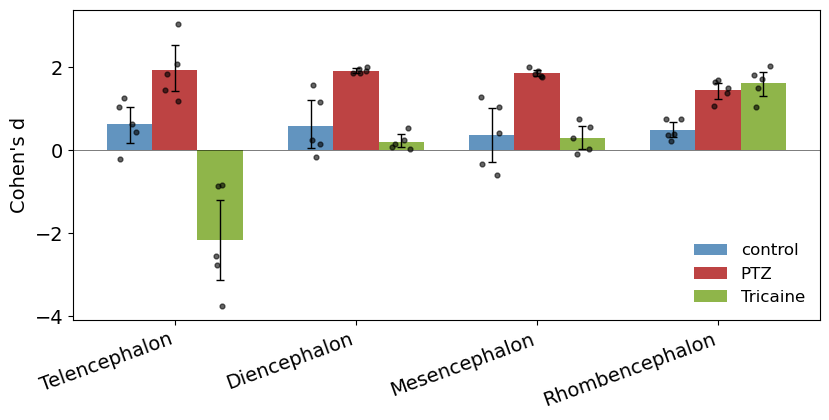

In [16]:
plot_metric_by_division(pfd, 'cohens_d', ylabel="Cohen's d",
                        path_to_save=f'{outdir}/cohens_d_by_division_full_mean_{variant}.pdf')

**Full window versus late plateau comparison**

In [17]:
comparison = (summary_division[summary_division.event == 'mean']
              .pivot_table(index=['compound', 'major'], columns='mode',
                           values='dff_change_mean'))
comparison['full_minus_plateau'] = comparison['full'] - comparison['plateau']
comparison.round(3)

mode                       full  plateau  full_minus_plateau
compound major                                              
PTZ      Diencephalon     0.285    0.327              -0.042
         Mesencephalon    0.241    0.284              -0.043
         Rhombencephalon  0.140    0.172              -0.033
         Telencephalon    0.141    0.076               0.065
Tricaine Diencephalon     0.012    0.020              -0.008
         Mesencephalon    0.013    0.024              -0.011
         Rhombencephalon  0.066    0.060               0.005
         Telencephalon   -0.098   -0.103               0.006
control  Diencephalon     0.017    0.017              -0.000
         Mesencephalon    0.007    0.012              -0.005
         Rhombencephalon  0.020    0.021              -0.001
         Telencephalon    0.027    0.002               0.025